# Task 2: Cuisine Combination

## Objective

1. Identify the most common combinations of cuisines in the dataset.
2. Determine whether certain cuisine combinations tend to have higher ratings.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://raw.githubusercontent.com/You-sha/Restaurant-Ratings-Prediction/master/zomato.csv"

df = pd.read_csv(url, encoding="ISO-8859-1")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (9551, 21)


In [3]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [4]:
cuisine_df = df[["Restaurant Name", "Cuisines", "Aggregate rating"]].copy()

cuisine_df.head()

,Restaurant Name,Cuisines,Aggregate rating
0,Le Petit Souffle,"French, Japanese, Desserts",4.8
1,Izakaya Kikufuji,Japanese,4.5
2,Heat - Edsa Shangri-La,"Seafood, Asian, Filipino, Indian",4.4
3,Ooma,"Japanese, Sushi",4.9
4,Sambo Kojin,"Japanese, Korean",4.8


In [5]:
print("Missing cuisines:", cuisine_df["Cuisines"].isnull().sum())

cuisine_df = cuisine_df.dropna(subset=["Cuisines"])

print("Remaining records:", len(cuisine_df))

Missing cuisines: 9
Remaining records: 9542


In [6]:
cuisine_df["Cuisines"] = (
    cuisine_df["Cuisines"]
    .str.split(",")
    .apply(lambda x: ", ".join(sorted([c.strip() for c in x])))
)

cuisine_df.head()

,Restaurant Name,Cuisines,Aggregate rating
0,Le Petit Souffle,"Desserts, French, Japanese",4.8
1,Izakaya Kikufuji,Japanese,4.5
2,Heat - Edsa Shangri-La,"Asian, Filipino, Indian, Seafood",4.4
3,Ooma,"Japanese, Sushi",4.9
4,Sambo Kojin,"Japanese, Korean",4.8


In [7]:
combination_counts = (
    cuisine_df["Cuisines"]
    .value_counts()
    .reset_index()
)

combination_counts.columns = ["Cuisine Combination", "Restaurant Count"]

combination_counts.head(10)

,Cuisine Combination,Restaurant Count
0,North Indian,936
1,"Chinese, North Indian",616
2,"Mughlai, North Indian",394
3,Fast Food,354
4,Chinese,354
5,"Chinese, Mughlai, North Indian",306
6,Cafe,299
7,Bakery,218
8,"Bakery, Desserts",181
9,"Chinese, Fast Food",159


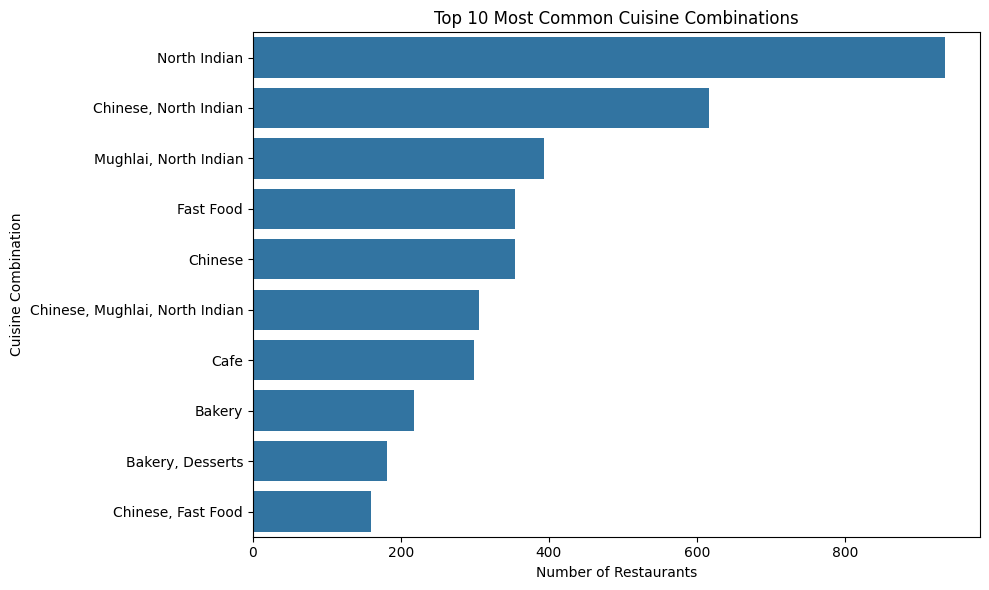

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=combination_counts.head(10),
    x="Restaurant Count",
    y="Cuisine Combination"
)

plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Combination")

plt.tight_layout()
plt.show()

In [9]:
rating_analysis = (
    cuisine_df
    .groupby("Cuisines")
    .agg(
        Restaurant_Count=("Aggregate rating", "count"),
        Average_Rating=("Aggregate rating", "mean")
    )
    .reset_index()
)

rating_analysis = rating_analysis.sort_values(
    "Restaurant_Count",
    ascending=False
)

rating_analysis.head(10)

,Cuisines,Restaurant_Count,Average_Rating
1290,North Indian,936,1.672329
876,"Chinese, North Indian",616,2.333442
1274,"Mughlai, North Indian",394,2.767259
712,Chinese,354,2.042090
1051,Fast Food,354,2.118362
866,"Chinese, Mughlai, North Indian",306,2.619935
589,Cafe,299,2.890970
326,Bakery,218,1.924312
378,"Bakery, Desserts",181,2.375691
779,"Chinese, Fast Food",159,2.069811


In [10]:
reliable_combinations = rating_analysis[
    rating_analysis["Restaurant_Count"] >= 10
].copy()

reliable_combinations = reliable_combinations.sort_values(
    "Average_Rating",
    ascending=False
)

reliable_combinations.head(10)

,Cuisines,Restaurant_Count,Average_Rating
1270,Modern Indian,11,4.345455
1149,Indian,18,4.250000
1316,Seafood,14,4.114286
626,"Cafe, Continental, Italian",18,4.111111
1337,Thai,16,4.100000
54,"American, Burger",16,4.068750
1209,"Japanese, Sushi",20,4.060000
347,"Bakery, Cafe, Desserts",11,4.027273
238,"Asian, Chinese, Thai",19,3.773684
841,"Chinese, Japanese, Thai",11,3.672727


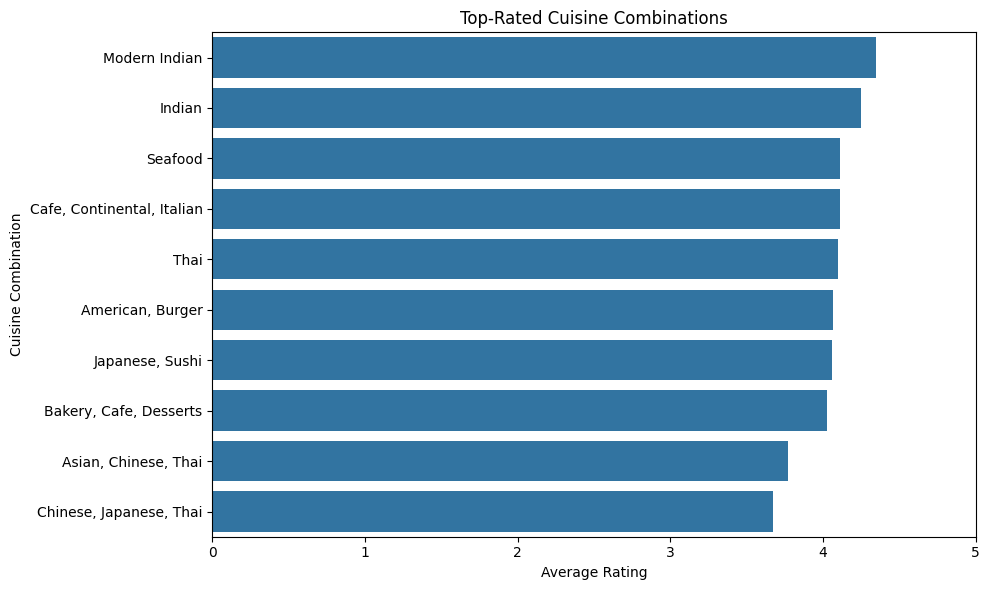

In [11]:
top_rated = reliable_combinations.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_rated,
    x="Average_Rating",
    y="Cuisines"
)

plt.title("Top-Rated Cuisine Combinations")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Combination")

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [12]:
print("Top 10 Most Common Cuisine Combinations")
display(combination_counts.head(10))

print("\nTop 10 Highest-Rated Cuisine Combinations")
display(
    reliable_combinations[
        ["Cuisines", "Restaurant_Count", "Average_Rating"]
    ].head(10)
)

Top 10 Most Common Cuisine Combinations


,Cuisine Combination,Restaurant Count
0,North Indian,936
1,"Chinese, North Indian",616
2,"Mughlai, North Indian",394
3,Fast Food,354
4,Chinese,354
5,"Chinese, Mughlai, North Indian",306
6,Cafe,299
7,Bakery,218
8,"Bakery, Desserts",181
9,"Chinese, Fast Food",159



Top 10 Highest-Rated Cuisine Combinations


,Cuisines,Restaurant_Count,Average_Rating
1270,Modern Indian,11,4.345455
1149,Indian,18,4.250000
1316,Seafood,14,4.114286
626,"Cafe, Continental, Italian",18,4.111111
1337,Thai,16,4.100000
54,"American, Burger",16,4.068750
1209,"Japanese, Sushi",20,4.060000
347,"Bakery, Cafe, Desserts",11,4.027273
238,"Asian, Chinese, Thai",19,3.773684
841,"Chinese, Japanese, Thai",11,3.672727


In [13]:
combination_counts.to_csv(
    "task2_cuisine_combination_counts.csv",
    index=False
)

reliable_combinations.to_csv(
    "task2_cuisine_rating_analysis.csv",
    index=False
)

print("Task 2 result files saved successfully!")

Task 2 result files saved successfully!


# Conclusion

The cuisine combination analysis identified the most common combinations
of cuisines served by restaurants in the dataset.

The analysis also compared the average ratings of different cuisine
combinations. To avoid misleading results from combinations represented
by very few restaurants, combinations with fewer than 10 restaurants
were excluded from the high-rating comparison.

The results show that cuisine combinations differ in both popularity
and average customer ratings. Some combinations have higher average
ratings than others, indicating that cuisine type and combination may
be associated with restaurant ratings.

However, average rating alone does not prove that a cuisine combination
causes higher ratings because other factors such as location, price,
restaurant quality, and number of reviews may also influence ratings.